In [ ]:
# Initial Analysis 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import shap

df = pd.read_csv("/Users/obedfrimpong/Desktop/qss-45-final-project/EJI_2024_United_States.csv")
df.head()

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,...,E_AIAN,NHPI,E_NHPI,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag
0,1,1,20804,140000US01001020804,1001020804,1001020804,Autauga County,Alabama,AL,Census Tract 208.04; Autauga County; Alabama,...,0.0,0,0.0,156,2.8,26,0.5,0.0,-999,-999
1,1,3,10706,140000US01003010706,1003010706,1003010706,Baldwin County,Alabama,AL,Census Tract 107.06; Baldwin County; Alabama,...,0.0,0,0.0,77,1.8,0,0.0,0.0,-999,-999
2,1,3,11503,140000US01003011503,1003011503,1003011503,Baldwin County,Alabama,AL,Census Tract 115.03; Baldwin County; Alabama,...,0.0,0,0.0,232,2.8,0,0.0,0.0,-999,-999
3,1,3,11604,140000US01003011604,1003011604,1003011604,Baldwin County,Alabama,AL,Census Tract 116.04; Baldwin County; Alabama,...,0.0,0,0.0,34,1.2,33,1.1,0.0,-999,-999
4,1,5,950100,140000US01005950100,1005950100,1005950100,Barbour County,Alabama,AL,Census Tract 9501; Barbour County; Alabama,...,0.0,0,0.0,47,1.7,74,2.7,0.0,-999,-999


In [2]:
# EJI 2024 Data Dictionary
# Variables beginning with "E_" are estimates. Variables beginning with "EPL" are percentile ranks for those estimates. 
# Variables beginning with "SPL_" are summed indicator or module ranks for domains, modules, or overall scores, 
#and variables beginning with "RPL_" are percentile ranks for domains, modules, or overall scores. 
# Values of -999 represent "null" or "no data". 
# Census tract boundaries are taken from 2020 TIGER/Line Files and are based on the 2020 decennial census.

# E_ = estimate (raw value), EPL_ = percentile, SPL_ = sum of percentiles, RPL_ = ranked percentile
# Key outcome: RPL_EJI is the overall Environmental Justice Index ranking (0-1)

In [3]:
df.iloc[:, 1:19]

,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,E_TOTPOP,M_TOTPOP,E_DAYPOP,SPL_EJI,RPL_EJI,SPL_SER,RPL_SER,SPL_EJI_CBM,RPL_EJI_CBM
0,1,20804,140000US01001020804,1001020804,1001020804,Autauga County,Alabama,AL,Census Tract 208.04; Autauga County; Alabama,5497,765,4677,0.1984,0.0117,0.1984,0.0259,0.3427,0.0033
1,3,10706,140000US01003010706,1003010706,1003010706,Baldwin County,Alabama,AL,Census Tract 107.06; Baldwin County; Alabama,4211,476,2672,0.4449,0.0620,0.2449,0.0390,1.0690,0.1261
2,3,11503,140000US01003011503,1003011503,1003011503,Baldwin County,Alabama,AL,Census Tract 115.03; Baldwin County; Alabama,8252,1187,13953,1.4904,0.6174,0.8904,0.4283,2.1322,0.6773
3,3,11604,140000US01003011604,1003011604,1003011604,Baldwin County,Alabama,AL,Census Tract 116.04; Baldwin County; Alabama,2913,375,1106,0.9583,0.3027,0.3583,0.0781,1.8128,0.5041
4,5,950100,140000US01005950100,1005950100,1005950100,Barbour County,Alabama,AL,Census Tract 9501; Barbour County; Alabama,2789,354,4587,1.4961,0.6207,1.0961,0.5943,2.2564,0.7367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85183,59,957700,140000US54059957700,54059957700,54059957700,Mingo County,West Virginia,WV,Census Tract 9577; Mingo County; West Virginia,3129,393,2399,1.7558,0.7478,0.7558,0.3199,2.2118,0.7161
85184,61,11000,140000US54061011000,54061011000,54061011000,Monongalia County,West Virginia,WV,Census Tract 110; Monongalia County; West Virg...,4030,403,11901,2.0018,0.8466,1.6018,0.8847,2.2122,0.7163
85185,9,250500,140000US72009250500,72009250500,72009250500,Aibonito Municipio,Puerto Rico,PR,Census Tract 2505; Aibonito Municipio; Puerto ...,-999,-999,-999,-999.0000,-999.0000,-999.0000,-999.0000,-999.0000,-999.0000
85186,13,300200,140000US72013300200,72013300200,72013300200,Arecibo Municipio,Puerto Rico,PR,Census Tract 3002; Arecibo Municipio; Puerto Rico,-999,-999,-999,-999.0000,-999.0000,-999.0000,-999.0000,-999.0000,-999.0000


In [4]:
df.iloc[:, 20:23]

,EPL_MINRTY,SPL_SVM_DOM1,RPL_SVM_DOM1
0,0.4360,0.4360,0.4360
1,0.2628,0.2628,0.2628
2,0.3773,0.3773,0.3773
3,0.0519,0.0519,0.0519
4,0.6913,0.6913,0.6913
...,...,...,...
85183,0.0216,0.0216,0.0216
85184,0.3385,0.3385,0.3385
85185,-999.0000,-999.0000,-999.0000
85186,-999.0000,-999.0000,-999.0000


In [5]:
df.iloc[:, 24:39]

,EPL_POV200,E_NOHSDP,EPL_NOHSDP,E_UNEMP,EPL_UNEMP,E_RENTER,EPL_RENTER,E_HOUBDN,EPL_HOUBDN,E_UNINSUR,EPL_UNINSUR,E_NOINT,EPL_NOINT,SPL_SVM_DOM2,RPL_SVM_DOM2
0,0.2902,5.8,0.3411,1.1,0.0773,12.2,0.1640,18.0,0.2735,3.5,0.2412,1.5,0.0547,1.4420,0.0869
1,0.2093,1.3,0.0561,5.4,0.5849,14.0,0.2018,10.0,0.0514,8.3,0.5899,5.7,0.2606,1.9540,0.1685
2,0.6907,16.4,0.7702,1.0,0.0694,35.1,0.5786,36.8,0.8037,18.6,0.9023,10.0,0.4787,4.2936,0.6878
3,0.4999,7.1,0.4202,5.3,0.5748,5.2,0.0449,10.6,0.0614,8.7,0.6100,17.9,0.7721,2.9833,0.3813
4,0.6881,14.0,0.7091,14.7,0.9547,14.8,0.2186,20.9,0.3800,7.7,0.5543,27.7,0.9319,4.4367,0.7190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85183,0.7446,37.9,0.9722,5.0,0.5426,21.3,0.3529,14.1,0.1430,4.8,0.3519,14.9,0.6788,3.7860,0.5711
85184,0.7708,5.1,0.2959,8.7,0.8178,54.6,0.7889,34.3,0.7584,14.4,0.8223,10.2,0.4877,4.7418,0.7797
85185,-999.0000,-999.0,-999.0000,-999.0,-999.0000,-999.0,-999.0000,-999.0,-999.0000,-999.0,-999.0000,-999.0,-999.0000,-999.0000,-999.0000
85186,-999.0000,-999.0,-999.0000,-999.0,-999.0000,-999.0,-999.0000,-999.0,-999.0000,-999.0,-999.0000,-999.0,-999.0000,-999.0000,-999.0000


In [6]:
import xgboost as xgb

In [7]:
df = df.replace(-999, np.nan)

key_vars = [
    'RPL_EJI',       # Overall EJI rank (target)
    'RPL_SVM',       # Social Vulnerability rank
    'RPL_EBM',       # Environmental Burden rank
    'RPL_HVM',       # Health Vulnerability rank
    'E_TOTPOP',      # Total population
    'E_MINRTY',      # % minority
    'E_POV200',      # % below 200% poverty
    'E_NOHSDP',      # % no high school diploma
    'E_UNEMP',       # % unemployed
    'E_RENTER',      # % renters
    'E_HOUBDN',      # % housing burdened
    'E_UNINSUR',     # % uninsured
    'E_NOINT',       # % no internet
    'E_AGE65',       # % age 65+
    'E_AGE17',       # % age 17 and under
    'E_DISABL',      # % disabled
    'E_OZONE',       # Ozone level
    'E_PM',          # PM2.5
    'E_DSLPM',       # Diesel PM
    'E_TOTCR',       # Total cancer risk
    'E_PARK',        # % near park
    'E_HOUAGE',      # % housing built pre-1980
    'E_ASTHMA',      # % with asthma
    'E_CANCER',      # % with cancer
    'E_DIABETES',    # % with diabetes
    'E_MHLTH',       # % poor mental health
]

# Drop rows with missing target
df_clean = df.dropna(subset=['RPL_EJI']).copy()

# For features, fill with median
for col in key_vars[1:]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"\nCleaned shape: {df_clean.shape}")


Cleaned shape: (82740, 170)


In [8]:
df_clean.head()

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,...,E_AIAN,NHPI,E_NHPI,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag
0,1,1,20804,140000US01001020804,1001020804,1001020804,Autauga County,Alabama,AL,Census Tract 208.04; Autauga County; Alabama,...,0.0,0.0,0.0,156.0,2.8,26.0,0.5,0.0,-999,NaN
1,1,3,10706,140000US01003010706,1003010706,1003010706,Baldwin County,Alabama,AL,Census Tract 107.06; Baldwin County; Alabama,...,0.0,0.0,0.0,77.0,1.8,0.0,0.0,0.0,-999,NaN
2,1,3,11503,140000US01003011503,1003011503,1003011503,Baldwin County,Alabama,AL,Census Tract 115.03; Baldwin County; Alabama,...,0.0,0.0,0.0,232.0,2.8,0.0,0.0,0.0,-999,NaN
3,1,3,11604,140000US01003011604,1003011604,1003011604,Baldwin County,Alabama,AL,Census Tract 116.04; Baldwin County; Alabama,...,0.0,0.0,0.0,34.0,1.2,33.0,1.1,0.0,-999,NaN
4,1,5,950100,140000US01005950100,1005950100,1005950100,Barbour County,Alabama,AL,Census Tract 9501; Barbour County; Alabama,...,0.0,0.0,0.0,47.0,1.7,74.0,2.7,0.0,-999,NaN


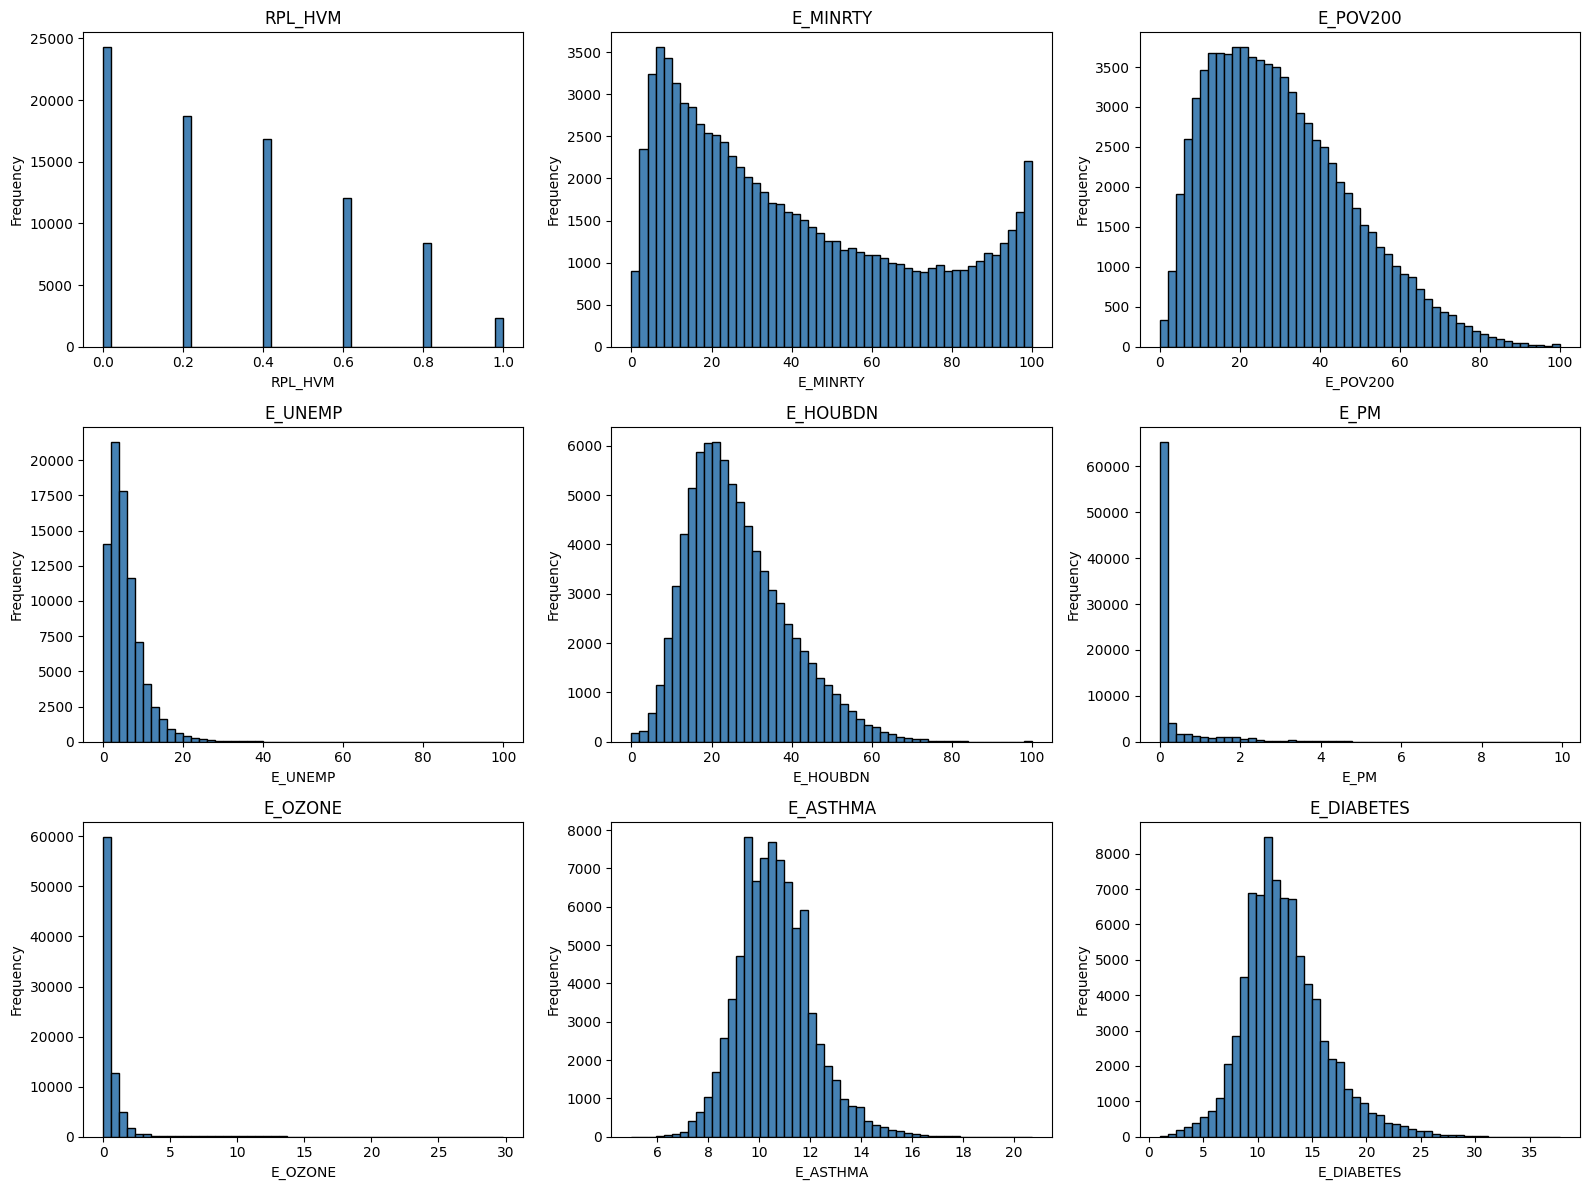

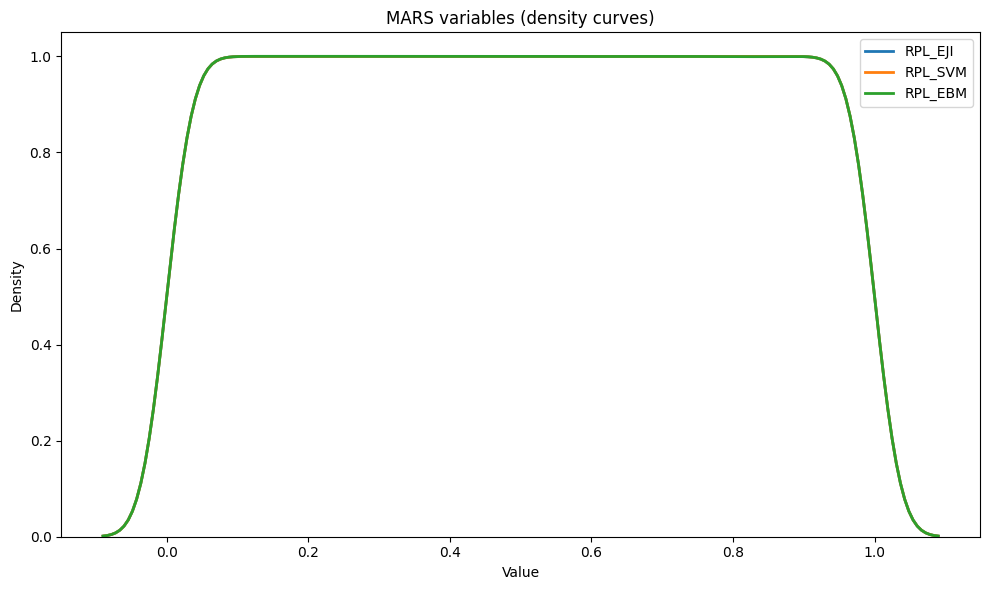

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

mars = ['RPL_EJI', 'RPL_SVM', 'RPL_EBM']
plot_vars = ['RPL_HVM', 'E_MINRTY', 'E_POV200', 'E_UNEMP', 'E_HOUBDN',
             'E_PM', 'E_OZONE', 'E_ASTHMA', 'E_DIABETES']

out = Path('output')
out.mkdir(exist_ok=True)

# Figure 1: Histograms for non-MARS variables
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, var in zip(axes.flat, plot_vars):
    data = pd.to_numeric(df_clean[var], errors='coerce').dropna()
    ax.hist(data, bins=50, color='steelblue', edgecolor='black')
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel('Frequency')

for ax in axes.flat[len(plot_vars):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(out / 'histograms_non_mars.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: Density curves for MARS variables
fig, ax = plt.subplots(figsize=(10, 6))

for var in mars:
    data = pd.to_numeric(df_clean[var], errors='coerce').dropna()
    sns.kdeplot(data, ax=ax, label=var, linewidth=2)

ax.set_title('MARS variables (density curves)')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig(out / 'mars_density_curves.png', dpi=150, bbox_inches='tight')
plt.show()

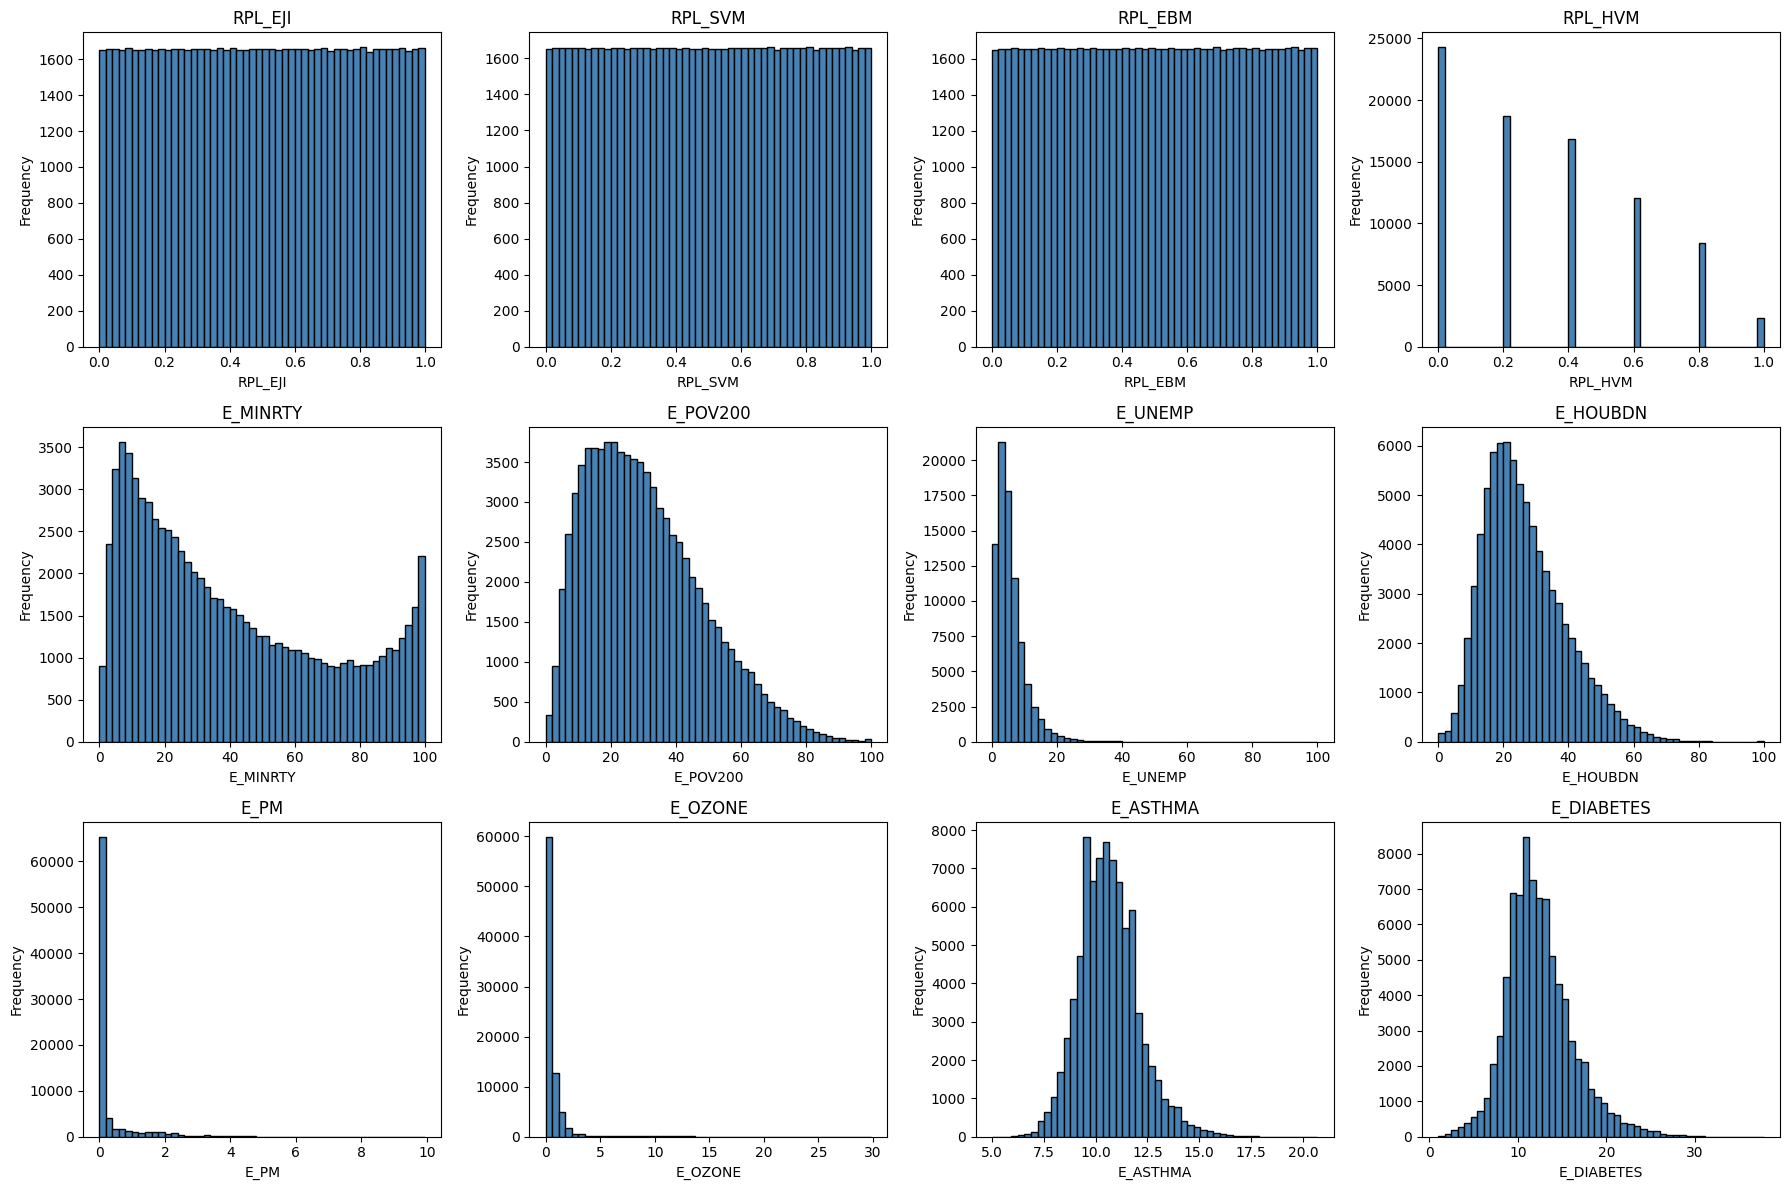

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
plot_vars = ['RPL_EJI', 'RPL_SVM', 'RPL_EBM','RPL_HVM',
             'E_MINRTY', 'E_POV200', 'E_UNEMP', 'E_HOUBDN',
             'E_PM', 'E_OZONE', 'E_ASTHMA', 'E_DIABETES']

#These variables weren't showing good graphs
mars = ['RPL_EJI', 'RPL_SVM', 'RPL_EBM']

for ax, var in zip(axes.flat, plot_vars):
    ax.hist(df_clean[var].dropna(), bins=50, color='steelblue', edgecolor='black')
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Frequency")
    
plt.tight_layout()
plt.savefig("histograms.png", dpi=100)
plt.show()

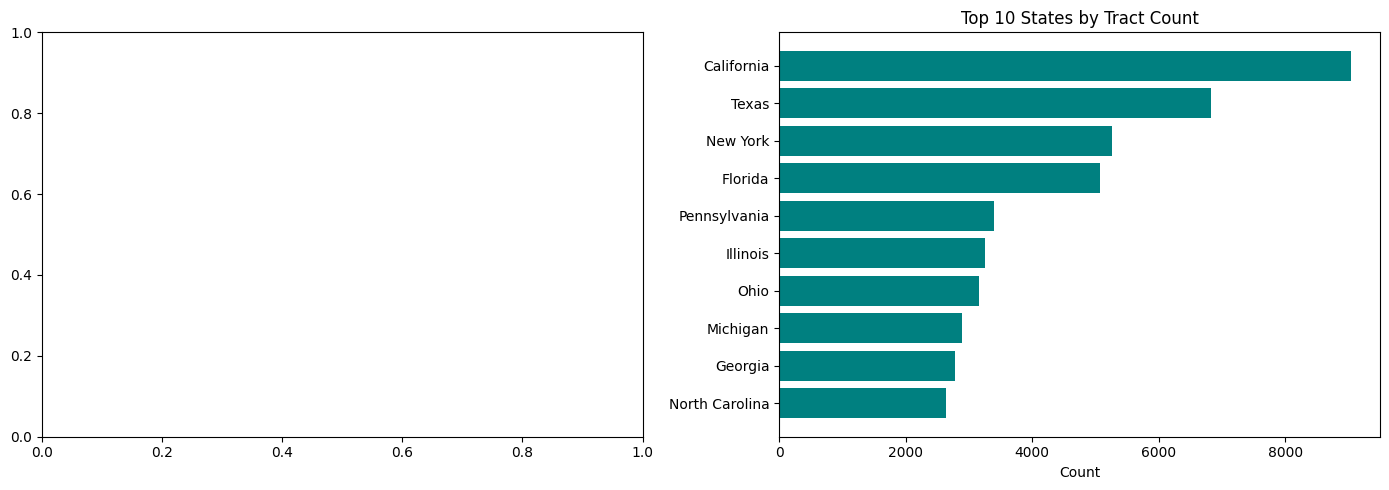

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 states by tract count
state_counts = df_clean['StateDesc'].value_counts().head(10)
axes[1].barh(state_counts.index[::-1], state_counts.values[::-1], color='teal')
axes[1].set_title("Top 10 States by Tract Count")
axes[1].set_xlabel("Count")
plt.tight_layout()
plt.savefig("barcharts.png", dpi=100)
plt.show()

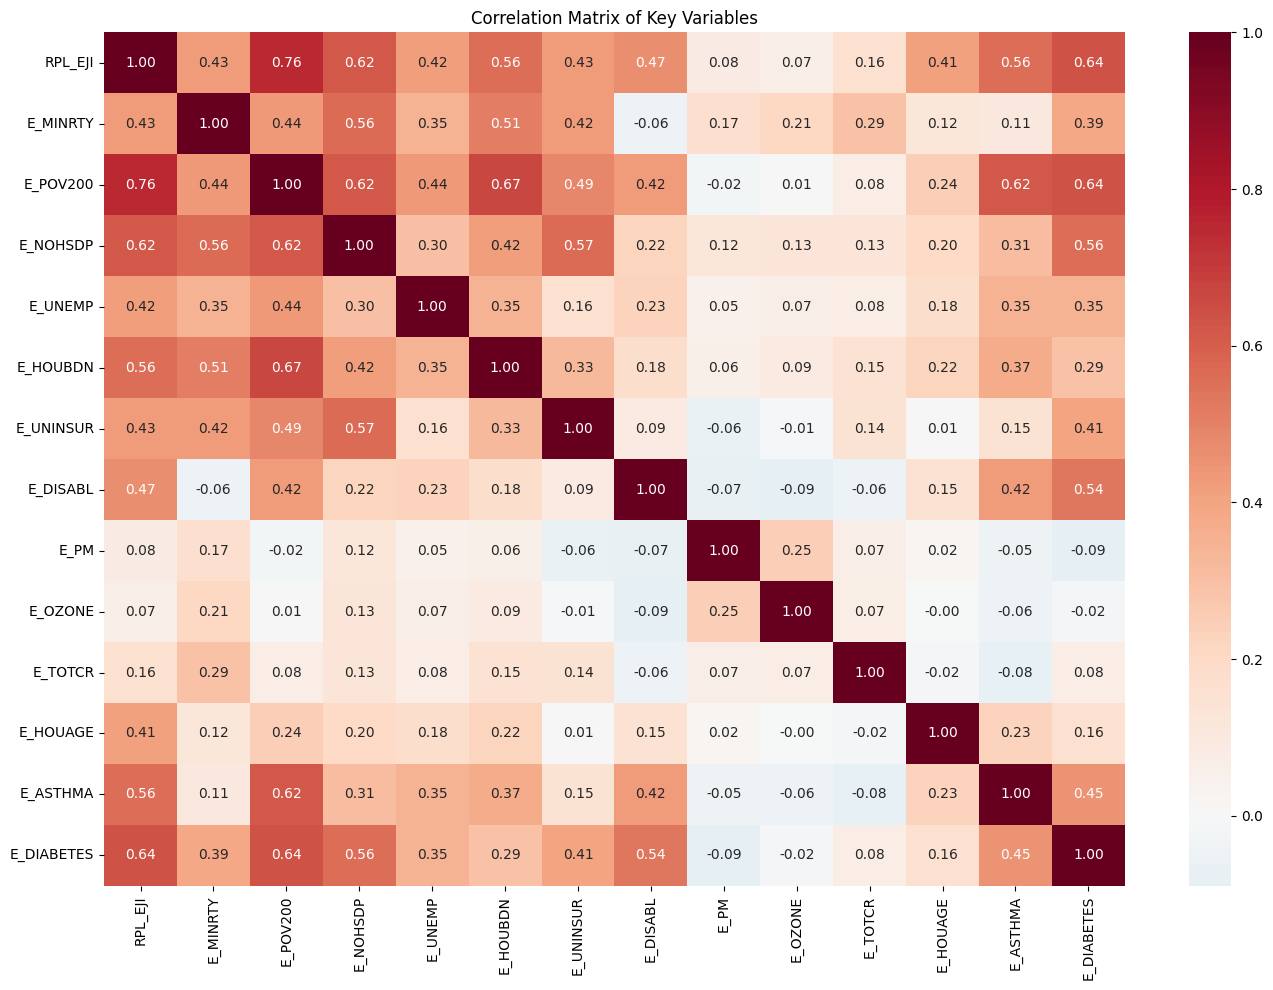

In [11]:
#Correlation matrix
plt.figure(figsize=(14, 10))
corr_vars = ['RPL_EJI', 'E_MINRTY', 'E_POV200', 'E_NOHSDP', 'E_UNEMP',
             'E_HOUBDN', 'E_UNINSUR', 'E_DISABL', 'E_PM', 'E_OZONE',
             'E_TOTCR', 'E_HOUAGE', 'E_ASTHMA', 'E_DIABETES']
sns.heatmap(df_clean[corr_vars].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title("Correlation Matrix of Key Variables")
plt.tight_layout()
plt.savefig("corr_heatmap.png", dpi=100)
plt.show()

In [12]:
features = ['E_MINRTY', 'E_POV200', 'E_NOHSDP', 'E_UNEMP', 'E_HOUBDN',
            'E_UNINSUR', 'E_NOINT', 'E_AGE65', 'E_DISABL', 'E_PM',
            'E_OZONE', 'E_DSLPM', 'E_TOTCR', 'E_HOUAGE', 'E_PARK',
            'E_ASTHMA', 'E_DIABETES', 'E_MHLTH']

X = df_clean[features]
y = df_clean['RPL_EJI']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (66192, 18), Test: (16548, 18)


In [13]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

X_train_sm = sm.add_constant(X_train_s)
X_test_sm  = sm.add_constant(X_test_s)

ols = sm.OLS(y_train, X_train_sm).fit()
print(ols.summary())

y_pred_ols = ols.predict(X_test_sm)
r2_ols = r2_score(y_test, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
print(f"\nOLS  R² (test): {r2_ols:.4f} | RMSE: {rmse_ols:.4f}")

                            OLS Regression Results                            
Dep. Variable:                RPL_EJI   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                 1.075e+04
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        18:19:11   Log-Likelihood:                 33569.
No. Observations:               66192   AIC:                        -6.710e+04
Df Residuals:                   66173   BIC:                        -6.693e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4997      0.001    882.184      0.0

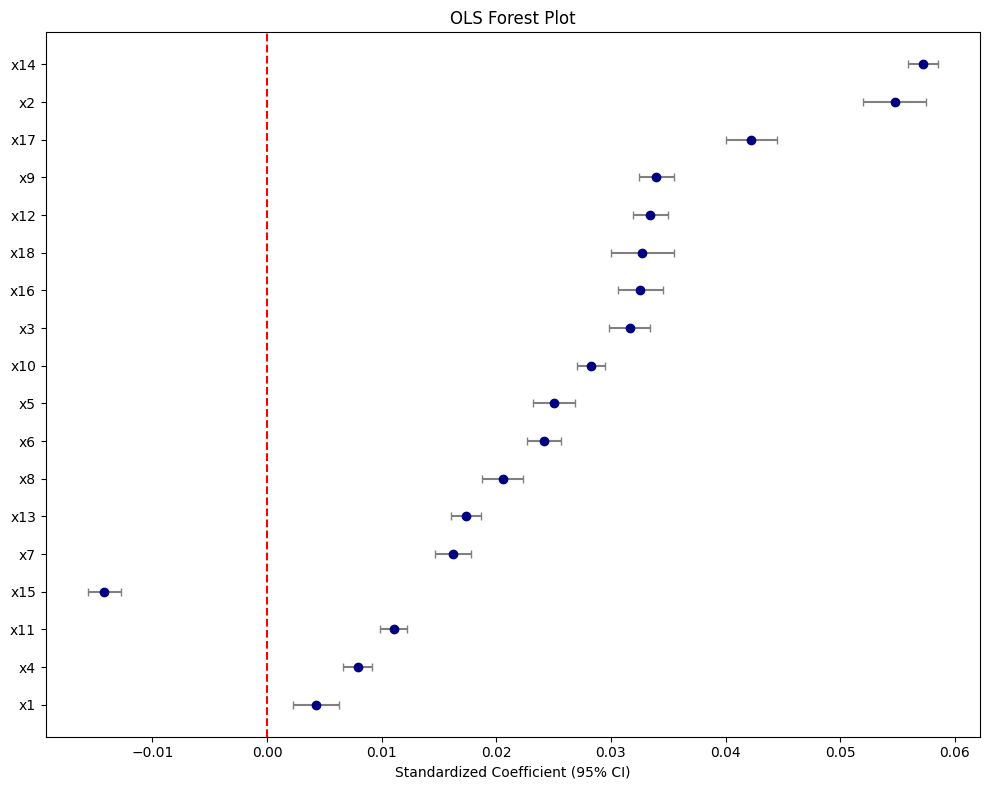

In [14]:
coefs = ols.params.iloc[1:].copy()
ci = ols.conf_int().iloc[1:].copy()
ci.index = coefs.index

order = coefs.abs().sort_values().index

plt.figure(figsize=(10, 8))
plt.errorbar(
    coefs.loc[order],
    range(len(order)),
    xerr=[
        coefs.loc[order] - ci.loc[order, 0],
        ci.loc[order, 1] - coefs.loc[order]
    ],
    fmt='o',
    color='navy',
    ecolor='gray',
    capsize=3
)
plt.axvline(0, color='red', linestyle='--')
plt.yticks(range(len(order)), order)
plt.xlabel("Standardized Coefficient (95% CI)")
plt.title("OLS Forest Plot")
plt.tight_layout()
plt.show()

In [15]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"XGB  R² (test): {r2_xgb:.4f} | RMSE: {rmse_xgb:.4f}")

XGB  R² (test): 0.8713 | RMSE: 0.1035


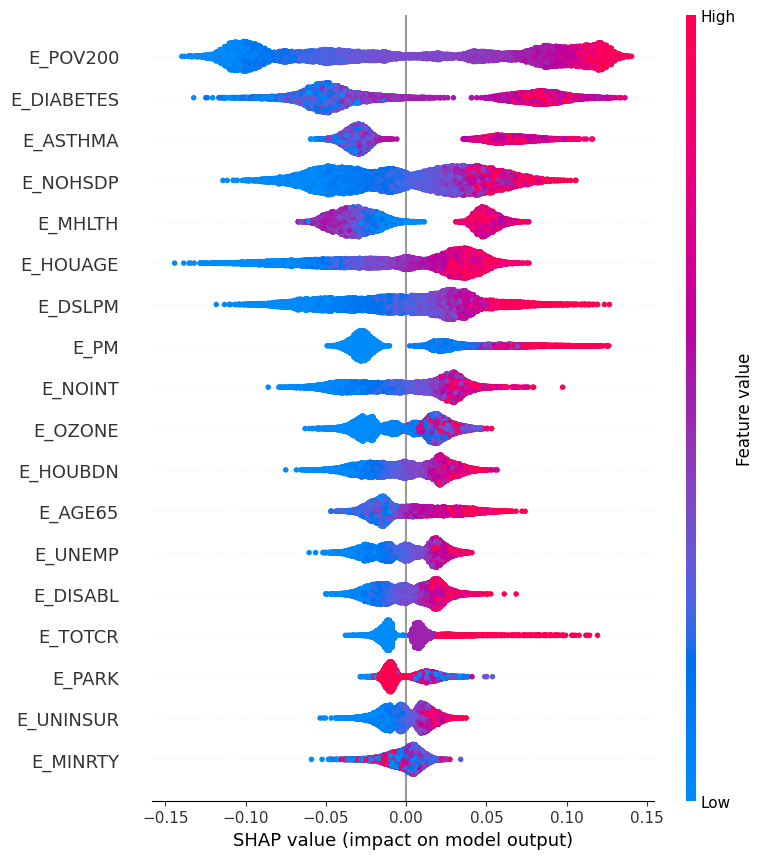

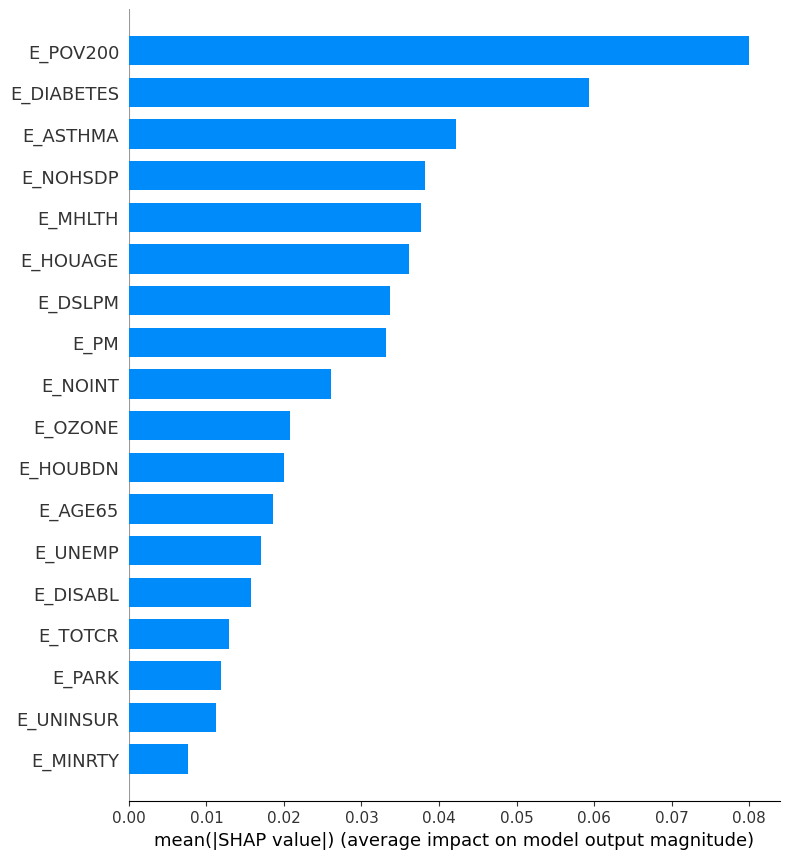

In [16]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=100)
plt.show()

shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=100)
plt.show()

In [17]:
comparison = pd.DataFrame({
    'Model': ['OLS', 'XGBoost'],
    'R²':    [r2_ols, r2_xgb],
    'RMSE':  [rmse_ols, rmse_xgb]
})
print(comparison)

     Model        R²      RMSE
0      OLS  0.749485  0.144436
1  XGBoost  0.871345  0.103508
